# Modal TabNet PEAD — Results Analysis

This notebook loads the outputs saved by `modal_tabnet_pead.py` and reproduces evaluation visuals.

## What was saved

The Modal pipeline wrote 4 files to the Modal Volume `tabnet-pead-output`:

| File | Contents | Format | Rows |
|---|---|---|---|
| `results.parquet` | Per-prediction table with all 12 columns | Parquet | ~9,937 (all test samples across 20 folds) |
| `per_fold_summary.parquet` | DA, MAE, RMSE per fold | Parquet | 20 |
| `histories_clf.json` | Per-epoch loss curves for every fold (classifier) | JSON | 20 folds × ~15 epochs |
| `histories_reg.json` | Per-epoch loss curves for every fold (regressor) | JSON | 20 folds × ~15 epochs |

## How to download

Run this from the repo root AFTER the Modal pipeline finishes:

```bash
python src/modeling/fetch_results.py
```

This pulls all 4 files from Modal Volume into `src/modeling/modal_tabnet_outputs/`.
No manual CLI commands needed.

In [1]:
import json
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({"figure.dpi": 100, "font.size": 9})

In [2]:
# Find modal_tabnet_outputs — try sibling dir first, then repo-relative
from pathlib import Path
output_dir = Path("modal_tabnet_outputs")
if not output_dir.exists():
    output_dir = Path("src") / "modeling" / "modal_tabnet_outputs"
DATA_DIR = str(output_dir)

results_path = f"{DATA_DIR}/results.parquet"
summary_path = f"{DATA_DIR}/per_fold_summary.parquet"
clf_hist_path = f"{DATA_DIR}/histories_clf.json"
reg_hist_path = f"{DATA_DIR}/histories_reg.json"

---
## 1. Load all outputs

In [3]:
# ── Results table: one row per prediction (symbol × earnings date) ──
results = pl.read_parquet(results_path)

# ── Per-fold summary: one row per test quarter ──────────────────────
summary = pl.read_parquet(summary_path)

# ── Loss histories: dict keyed by quarter ───────────────────────────
with open(clf_hist_path) as f:
    clf_histories = json.load(f)
with open(reg_hist_path) as f:
    reg_histories = json.load(f)

In [4]:
print(f"Results table: {results.shape}")
print(f"Columns: {results.columns}")
print(f"Quarters covered: {sorted(results['quarter'].unique().to_list())}")
print(f"Unique symbols: {results['symbol'].n_unique()}")
results.head(10)

Results table: (9937, 12)
Columns: ['quarter', 'fold_num', 'symbol', 'earnings_date', 'entry_price', 'target_class_actual', 'target_class_predicted', 'prob_class_0', 'prob_class_1', 'prob_class_2', 'target_return_actual', 'target_return_predicted']
Quarters covered: ['2021_Q1', '2021_Q2', '2021_Q3', '2021_Q4', '2022_Q1', '2022_Q2', '2022_Q3', '2022_Q4', '2023_Q1', '2023_Q2', '2023_Q3', '2023_Q4', '2024_Q1', '2024_Q2', '2024_Q3', '2024_Q4', '2025_Q1', '2025_Q2', '2025_Q3', '2025_Q4']
Unique symbols: 502


quarter,fold_num,symbol,earnings_date,entry_price,target_class_actual,target_class_predicted,prob_class_0,prob_class_1,prob_class_2,target_return_actual,target_return_predicted
str,i64,str,date,f64,i64,i64,f32,f32,f32,f64,f64
"""2021_Q1""",1,"""LYB""",2021-01-29,60.94038,2,2,0.244352,0.25865,0.496998,0.113199,0.060496
"""2021_Q1""",1,"""CPRT""",2021-02-18,29.2675,0,2,0.247706,0.285523,0.466772,-0.007175,0.037546
"""2021_Q1""",1,"""LIN""",2021-02-05,239.364243,0,2,0.257958,0.293684,0.448358,0.002837,0.043104
"""2021_Q1""",1,"""HBAN""",2021-01-22,10.690092,2,2,0.255461,0.277089,0.46745,0.061573,0.043904
"""2021_Q1""",1,"""VZ""",2021-01-26,39.989746,1,2,0.224845,0.262296,0.512859,0.021767,0.040608
"""2021_Q1""",1,"""PSA""",2021-02-24,194.3638,0,2,0.256961,0.303271,0.439768,0.006041,0.031971
"""2021_Q1""",1,"""CB""",2021-02-02,144.305573,2,2,0.259081,0.264075,0.476844,0.074234,0.003235
"""2021_Q1""",1,"""SATS""",2021-02-23,23.120001,2,2,0.274268,0.296507,0.429225,0.227076,0.026332
"""2021_Q1""",1,"""VLO""",2021-01-28,46.52261,2,2,0.198206,0.229509,0.572285,0.176813,0.072212


### Column descriptions

| Column | Type | Description |
|---|---|---|
| `quarter` | str | Test quarter label, e.g. `2021_Q1` |
| `fold_num` | int | Fold number (1–20) |
| `symbol` | str | Stock ticker |
| `earnings_date` | date | Earnings announcement date |
| `entry_price` | float | Close price at t+1 (entry) |
| `target_class_actual` | int | True class: 0=Low(<2%), 1=Moderate(2-4%), 2=Strong(≥4%) |
| `target_class_predicted` | int | TabNet predicted class |
| `prob_class_0` | float | Probability assigned to class 0 |
| `prob_class_1` | float | Probability assigned to class 1 |
| `prob_class_2` | float | Probability assigned to class 2 |
| `target_return_actual` | float | Actual peak return (target_return) |
| `target_return_predicted` | float | TabNet regressor prediction |

In [5]:
print(f"Per-fold summary: {summary.shape}")
summary

Per-fold summary: (20, 5)


quarter,fold_num,DA,MAE,RMSE
str,i64,f64,f64,f64
"""2021_Q1""",1,0.585366,0.040983,0.057417
"""2021_Q2""",2,0.393509,0.026736,0.039407
"""2021_Q3""",3,0.30426,0.025553,0.037855
"""2021_Q4""",4,0.367886,0.026037,0.0394
"""2022_Q1""",5,0.473684,0.038178,0.055877
…,…,…,…,…
"""2024_Q4""",16,0.450397,0.034007,0.063661
"""2025_Q1""",17,0.348606,0.024964,0.036527
"""2025_Q2""",18,0.612774,0.041148,0.064705


In [6]:
# ── Inspect one fold's history ──────────────────────────────────────
example_quarter = list(clf_histories.keys())[0]
print(f"Fold '{example_quarter}' classifier history keys: {list(clf_histories[example_quarter].keys())}")
print(f"  Epochs trained: {len(clf_histories[example_quarter].get('loss', []))}")
print(f"  Final train loss: {clf_histories[example_quarter]['loss'][-1]:.4f}")
print(f"  Final val logloss: {clf_histories[example_quarter]['val_logloss'][-1]:.4f}")
print()
print(f"Fold '{example_quarter}' regressor history keys: {list(reg_histories[example_quarter].keys())}")
print(f"  Epochs trained: {len(reg_histories[example_quarter].get('loss', []))}")
print(f"  Final train loss (RMSE): {reg_histories[example_quarter]['loss'][-1]:.4f}")
print(f"  Final val RMSE: {reg_histories[example_quarter]['val_rmse'][-1]:.4f}")

Fold '2021_Q1' classifier history keys: ['loss', 'lr', 'val_logloss']
  Epochs trained: 30
  Final train loss: 1.0329
  Final val logloss: 0.8612

Fold '2021_Q1' regressor history keys: ['loss', 'lr', 'val_rmse']
  Epochs trained: 11
  Final train loss (RMSE): 1.0777
  Final val RMSE: 3.2272


---
## 2. Per-Fold Evaluation Metrics

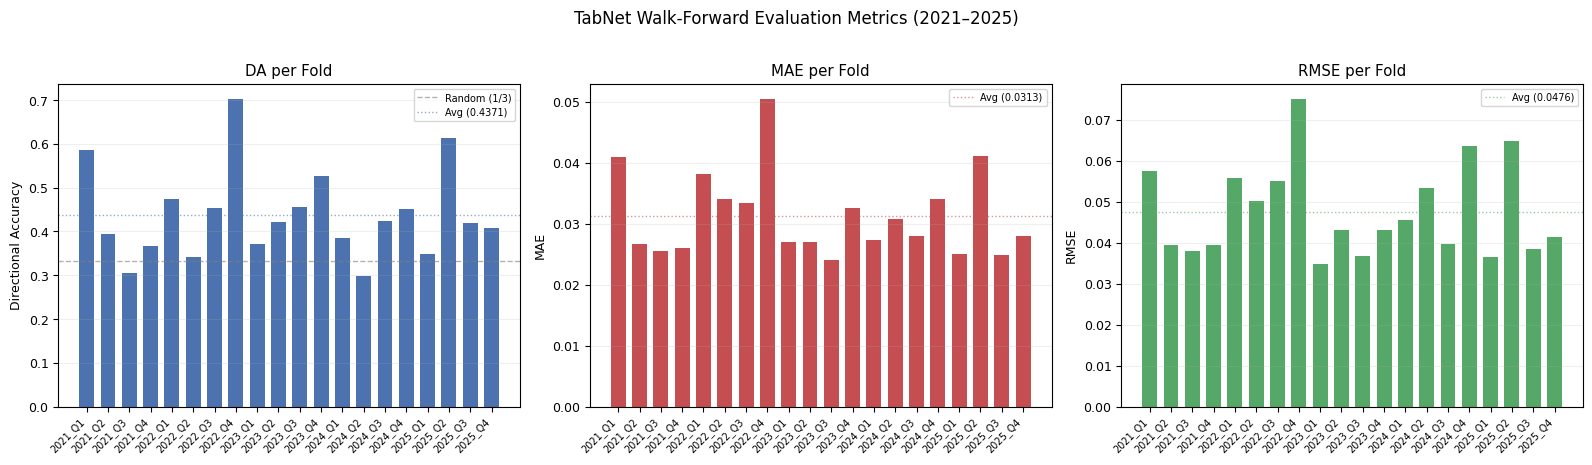

In [7]:
quarters = summary["quarter"].to_list()
da_vals = summary["DA"].to_numpy()
mae_vals = summary["MAE"].to_numpy()
rmse_vals = summary["RMSE"].to_numpy()

x = np.arange(len(quarters))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── DA ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.bar(x, da_vals, color="#4C72B0", width=0.7)
ax.axhline(1/3, color="gray", ls="--", lw=1, alpha=0.6, label="Random (1/3)")
ax.axhline(da_vals.mean(), color="#4C72B0", ls=":", lw=1, alpha=0.6,
          label=f"Avg ({da_vals.mean():.4f})")
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Directional Accuracy")
ax.set_title("DA per Fold")
ax.legend(fontsize=7)
ax.grid(alpha=0.2, axis="y")

# ── MAE ───────────────────────────────────────────────────────────────
ax = axes[1]
ax.bar(x, mae_vals, color="#C44E52", width=0.7)
ax.axhline(mae_vals.mean(), color="#C44E52", ls=":", lw=1, alpha=0.6,
          label=f"Avg ({mae_vals.mean():.4f})")
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("MAE")
ax.set_title("MAE per Fold")
ax.legend(fontsize=7)
ax.grid(alpha=0.2, axis="y")

# ── RMSE ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.bar(x, rmse_vals, color="#55A868", width=0.7)
ax.axhline(rmse_vals.mean(), color="#55A868", ls=":", lw=1, alpha=0.6,
          label=f"Avg ({rmse_vals.mean():.4f})")
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("RMSE")
ax.set_title("RMSE per Fold")
ax.legend(fontsize=7)
ax.grid(alpha=0.2, axis="y")

fig.suptitle("TabNet Walk-Forward Evaluation Metrics (2021–2025)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

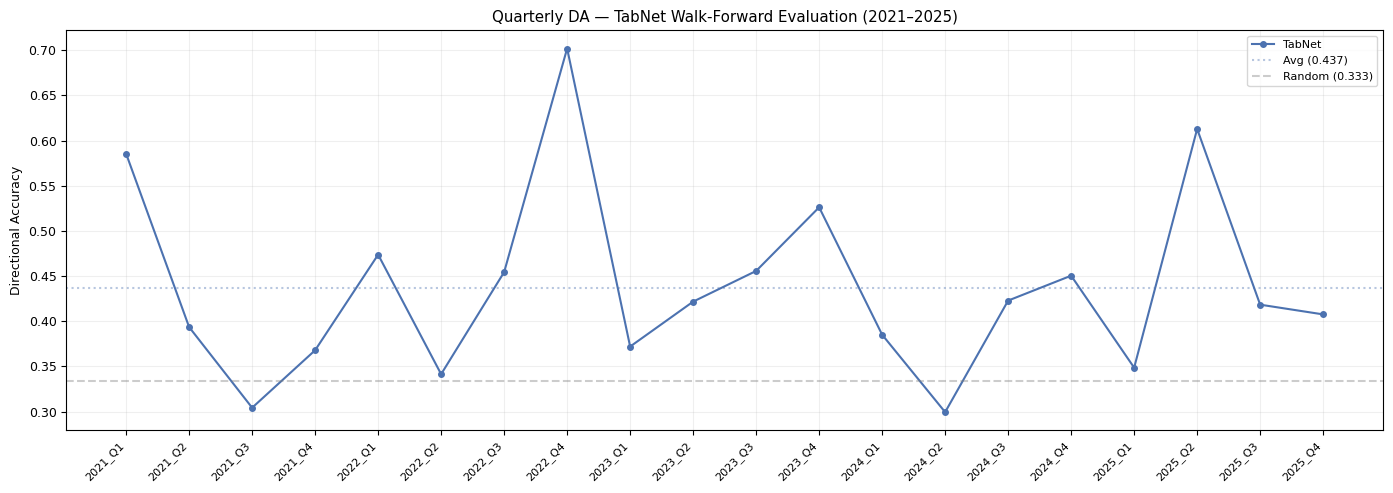

In [8]:
# ── Quarterly DA over time (line plot) ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, da_vals, marker="o", markersize=4, linewidth=1.5,
        color="#4C72B0", label="TabNet")
ax.axhline(da_vals.mean(), color="#4C72B0", linestyle=":",
           alpha=0.4, label=f"Avg ({da_vals.mean():.3f})")
ax.axhline(1/3, color="gray", linestyle="--", alpha=0.4, label="Random (0.333)")

ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Directional Accuracy")
ax.set_title("Quarterly DA — TabNet Walk-Forward Evaluation (2021–2025)")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [9]:
# ── Print per-fold summary table ─────────────────────────────────────
print(f"{'='*60}")
print("PER-FOLD SUMMARY")
print(f"{'='*60}")
print(f"{'Quarter':<12}  {'DA':>6}  {'MAE':>8}  {'RMSE':>8}")
print(f"{'-'*42}")
for row in summary.iter_rows():
    q, da, mae, rmse = row[0], row[2], row[3], row[4]
    print(f"{q:<12}  {da:.4f}  {mae:.4f}  {rmse:.4f}")
print(f"{'-'*42}")
avg_da = da_vals.mean()
avg_mae = mae_vals.mean()
avg_rmse = rmse_vals.mean()
print(f"{'Avg':<12}  {avg_da:.4f}  {avg_mae:.4f}  {avg_rmse:.4f}")

PER-FOLD SUMMARY
Quarter           DA       MAE      RMSE
------------------------------------------
2021_Q1       0.5854  0.0410  0.0574
2021_Q2       0.3935  0.0267  0.0394
2021_Q3       0.3043  0.0256  0.0379
2021_Q4       0.3679  0.0260  0.0394
2022_Q1       0.4737  0.0382  0.0559
2022_Q2       0.3414  0.0341  0.0501
2022_Q3       0.4544  0.0333  0.0550
2022_Q4       0.7018  0.0504  0.0750
2023_Q1       0.3720  0.0270  0.0347
2023_Q2       0.4217  0.0270  0.0432
2023_Q3       0.4556  0.0241  0.0367
2023_Q4       0.5261  0.0327  0.0431
2024_Q1       0.3851  0.0274  0.0456
2024_Q2       0.2994  0.0307  0.0533
2024_Q3       0.4228  0.0279  0.0397
2024_Q4       0.4504  0.0340  0.0637
2025_Q1       0.3486  0.0250  0.0365
2025_Q2       0.6128  0.0411  0.0647
2025_Q3       0.4183  0.0249  0.0385
2025_Q4       0.4076  0.0280  0.0413
------------------------------------------
Avg           0.4371  0.0313  0.0476


---
## 3. Confusion Matrix

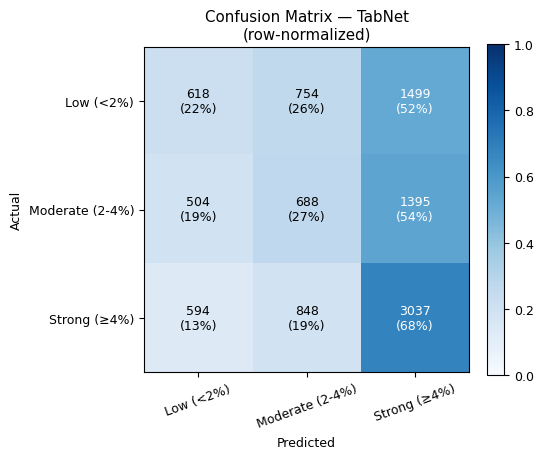

In [10]:
actual = results["target_class_actual"].to_numpy()
predicted = results["target_class_predicted"].to_numpy()

cm = confusion_matrix(actual, predicted)
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
cls_labels = ["Low (<2%)", "Moderate (2-4%)", "Strong (\u22654%)"]
ax.set_xticks(range(3))
ax.set_xticklabels(cls_labels, rotation=20)
ax.set_yticks(range(3))
ax.set_yticklabels(cls_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — TabNet\n(row-normalized)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]}\n({cm_pct[i,j]:.0%})",
                ha="center", va="center",
                color="white" if cm_pct[i,j] > 0.5 else "black")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

---
## 4. Loss Curves — Per-Fold Training History

Each subplot shows the classifier (blue) and regressor (green) training/validation loss per epoch.

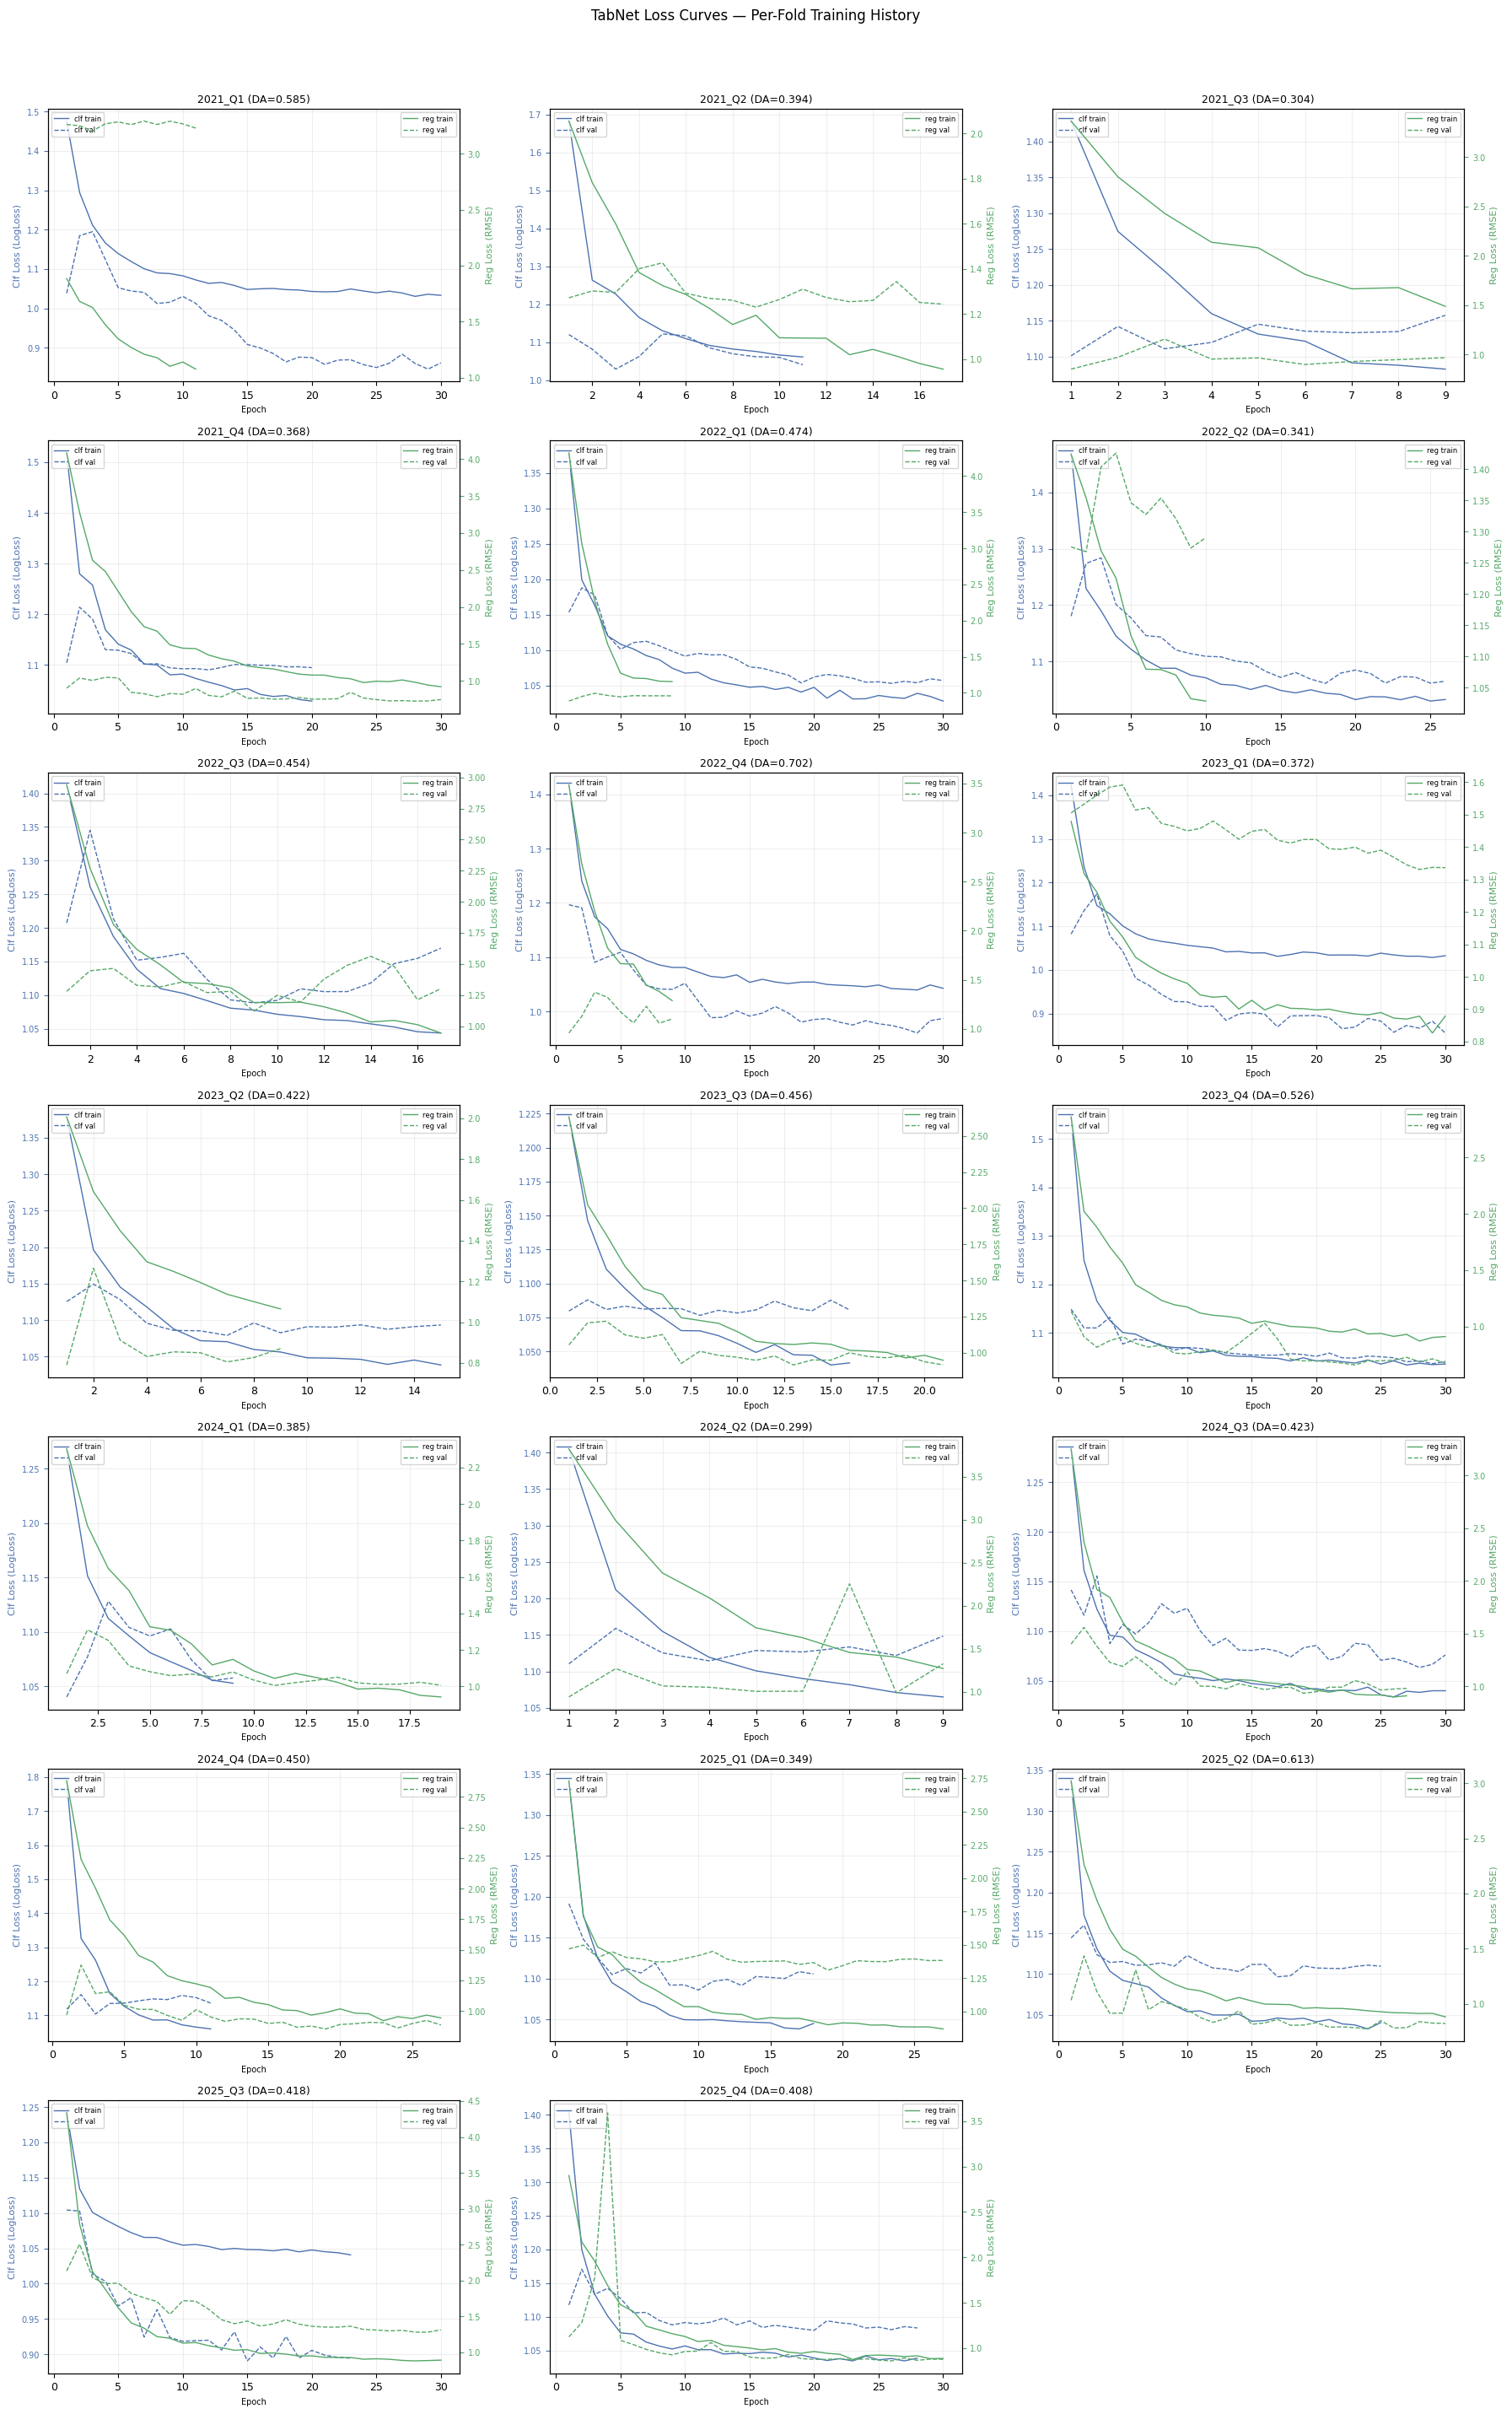

In [11]:
quarters_list = sorted(clf_histories.keys(),
                      key=lambda q: (int(q.split("_")[0]), int(q[6:])))
n_folds = len(quarters_list)
n_cols = 3
n_rows = (n_folds + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten() if n_folds > 1 else [axes]

for i, q in enumerate(quarters_list):
    ax = axes[i]

    # Classifier history
    ch = clf_histories[q]
    clf_epochs = range(1, len(ch.get("loss", [])) + 1)
    if "loss" in ch:
        ax.plot(clf_epochs, ch["loss"], label="clf train",
                color="#4C72B0", lw=1)
    if "val_logloss" in ch:
        ax.plot(clf_epochs, ch["val_logloss"], label="clf val",
                color="#4C72B0", ls="--", lw=1)

    # Regressor history (twin axis)
    ax_twin = ax.twinx()
    rh = reg_histories[q]
    reg_epochs = range(1, len(rh.get("loss", [])) + 1)
    if "loss" in rh:
        ax_twin.plot(reg_epochs, rh["loss"], label="reg train",
                     color="#55A868", lw=1)
    if "val_rmse" in rh:
        ax_twin.plot(reg_epochs, rh["val_rmse"], label="reg val",
                     color="#55A868", ls="--", lw=1)
    ax_twin.set_ylabel("Reg Loss (RMSE)", color="#55A868", fontsize=8)
    ax_twin.tick_params(axis="y", colors="#55A868", labelsize=7)
    ax_twin.legend(fontsize=6, loc="upper right")

    # Lookup DA for this quarter
    da_val = summary.filter(pl.col("quarter") == q)["DA"][0]
    ax.set_title(f"{q} (DA={da_val:.3f})", fontsize=9)
    ax.set_xlabel("Epoch", fontsize=7)
    ax.set_ylabel("Clf Loss (LogLoss)", color="#4C72B0", fontsize=8)
    ax.tick_params(axis="y", colors="#4C72B0", labelsize=7)
    ax.legend(fontsize=6, loc="upper left")
    ax.grid(alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("TabNet Loss Curves — Per-Fold Training History",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# ── Summary table of final per-epoch losses ──────────────────────────
print(f"\n{'=' * 72}")
print(f"{'FINAL LOSS PER FOLD':^72}")
print(f"{'=' * 72}")
print(f"{'Quarter':<12} {'Clf Train':>10} {'Clf Val':>10} "
      f"{'Reg Train':>10} {'Reg Val':>10}")
print(f"{'-' * 52}")

for q in quarters_list:
    ch = clf_histories[q]
    rh = reg_histories[q]
    ct = ch.get("loss", [float("nan")])[-1]
    cv = ch.get("val_logloss", [float("nan")])[-1]
    rt = rh.get("loss", [float("nan")])[-1]
    rv = rh.get("val_rmse", [float("nan")])[-1]
    print(f"{q:<12} {ct:>10.4f} {cv:>10.4f} {rt:>10.4f} {rv:>10.4f}")

print(f"{'-' * 52}")


                          FINAL LOSS PER FOLD                           
Quarter       Clf Train    Clf Val  Reg Train    Reg Val
----------------------------------------------------
2021_Q1          1.0329     0.8612     1.0777     3.2272
2021_Q2          1.0611     1.0406     0.9558     1.2437
2021_Q3          1.0825     1.1576     1.4869     0.9667
2021_Q4          1.0291     1.0949     0.9205     0.7473
2022_Q1          1.0281     1.0571     1.1546     0.9574
2022_Q2          1.0324     1.0647     1.0285     1.2902
2022_Q3          1.0436     1.1698     0.9446     1.3007
2022_Q4          1.0427     0.9870     1.2872     1.1008
2023_Q1          1.0323     0.8552     0.8787     1.3360
2023_Q2          1.0384     1.0932     1.0649     0.8702
2023_Q3          1.0415     1.0805     0.9479     0.9161
2023_Q4          1.0353     1.0408     0.9111     0.6767
2024_Q1          1.0528     1.0577     0.9425     1.0063
2024_Q2          1.0651     1.1485     1.2705     1.3251
2024_Q3          1

---
## 5. Actual Return Distribution by Predicted Class

If the classifier is useful, the median actual return should increase across predicted Low → Moderate → Strong.

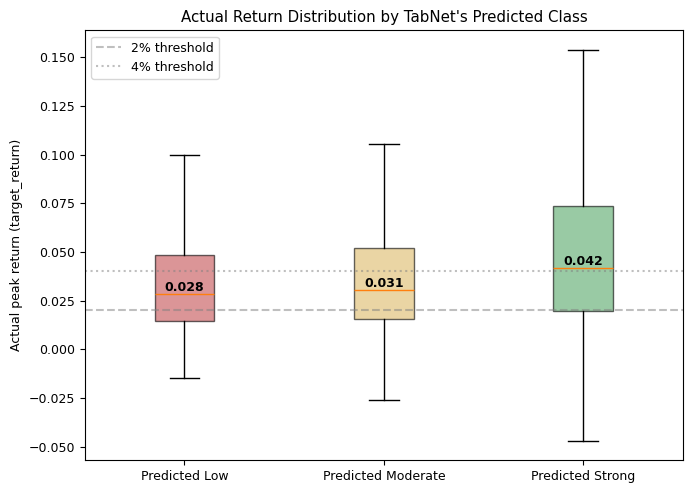

In [13]:
actual_returns = results["target_return_actual"].to_numpy()

data_by_class = [actual_returns[predicted == c] for c in [0, 1, 2]]

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(
    data_by_class,
    tick_labels=["Predicted Low", "Predicted Moderate", "Predicted Strong"],
    showfliers=False,
    patch_artist=True,
)
for patch, color in zip(bp["boxes"], ["#C44E52", "#DDB967", "#55A868"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for i, data in enumerate(data_by_class):
    median = np.median(data)
    ax.text(i + 1, median, f"{median:.3f}", ha="center", va="bottom",
            fontweight="bold", fontsize=9)

ax.axhline(0.02, color="gray", linestyle="--", alpha=0.5, label="2% threshold")
ax.axhline(0.04, color="gray", linestyle=":", alpha=0.5, label="4% threshold")
ax.set_ylabel("Actual peak return (target_return)")
ax.set_title("Actual Return Distribution by TabNet's Predicted Class")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Single Symbol Preview

Track one stock across all folds to see how predictions change over time.

In [14]:
example_symbols = ["AAPL", "COST", "GOOGL", "MSFT"]
for sym in example_symbols:
    df_sym = results.filter(pl.col("symbol") == sym)
    if len(df_sym) > 0:
        print(f"\n{sym} ({len(df_sym)} earnings events):")
        print(df_sym.select([
            "quarter", "earnings_date",
            "target_class_actual", "target_class_predicted",
            "target_return_actual", "target_return_predicted",
        ]))
        break  # show one for brevity, remove to see all


AAPL (20 earnings events):
shape: (20, 6)
┌─────────┬───────────────┬──────────────────┬─────────────────┬─────────────────┬─────────────────┐
│ quarter ┆ earnings_date ┆ target_class_act ┆ target_class_pr ┆ target_return_a ┆ target_return_p │
│ ---     ┆ ---           ┆ ual              ┆ edicted         ┆ ctual           ┆ redicted        │
│ str     ┆ date          ┆ ---              ┆ ---             ┆ ---             ┆ ---             │
│         ┆               ┆ i64              ┆ i64             ┆ f64             ┆ f64             │
╞═════════╪═══════════════╪══════════════════╪═════════════════╪═════════════════╪═════════════════╡
│ 2021_Q1 ┆ 2021-01-27    ┆ 0                ┆ 2               ┆ 0.007265        ┆ 0.049893        │
│ 2021_Q2 ┆ 2021-04-28    ┆ 0                ┆ 0               ┆ 0.00442         ┆ 0.029121        │
│ 2021_Q3 ┆ 2021-07-27    ┆ 1                ┆ 1               ┆ 0.021106        ┆ 0.047477        │
│ 2021_Q4 ┆ 2021-10-28    ┆ 0                ┆ 0

In [15]:
results

quarter,fold_num,symbol,earnings_date,entry_price,target_class_actual,target_class_predicted,prob_class_0,prob_class_1,prob_class_2,target_return_actual,target_return_predicted
str,i64,str,date,f64,i64,i64,f32,f32,f32,f64,f64
"""2021_Q1""",1,"""LYB""",2021-01-29,60.94038,2,2,0.244352,0.25865,0.496998,0.113199,0.060496
"""2021_Q1""",1,"""CPRT""",2021-02-18,29.2675,0,2,0.247706,0.285523,0.466772,-0.007175,0.037546
"""2021_Q1""",1,"""LIN""",2021-02-05,239.364243,0,2,0.257958,0.293684,0.448358,0.002837,0.043104
"""2021_Q1""",1,"""HBAN""",2021-01-22,10.690092,2,2,0.255461,0.277089,0.46745,0.061573,0.043904
"""2021_Q1""",1,"""VZ""",2021-01-26,39.989746,1,2,0.224845,0.262296,0.512859,0.021767,0.040608
…,…,…,…,…,…,…,…,…,…,…,…
"""2025_Q4""",20,"""BR""",2025-11-04,216.46933,2,2,0.287057,0.306445,0.406498,0.045521,0.050174
"""2025_Q4""",20,"""PCAR""",2025-10-21,97.656738,0,2,0.269654,0.281752,0.448594,0.018938,0.042144
"""2025_Q4""",20,"""TXT""",2025-10-23,81.183556,0,2,0.299265,0.319181,0.381554,0.001108,0.038774


---
## File reference

| File | Saved by Modal at | Loaded in this notebook from |
|---|---|---|
| `results.parquet` | `/out/results.parquet` (Modal Volume) | `./results.parquet` (downloaded) |
| `per_fold_summary.parquet` | `/out/per_fold_summary.parquet` | `./per_fold_summary.parquet` |
| `histories_clf.json` | `/out/histories_clf.json` | `./histories_clf.json` |
| `histories_reg.json` | `/out/histories_reg.json` | `./histories_reg.json` |

To re-run the pipeline with different parameters, edit the `CLF_DEFAULTS` / `REG_DEFAULTS`
dictionaries at the top of `modal_tabnet_pead.py`, then:

```bash
modal run src/modeling/modal_tabnet_pead.py
```

In [16]:
print("""### DNN Results Summary
                 precision    recall  f1-score   support

      Low (<2%)       0.38      0.29      0.33      2871
Moderate (2-4%)       0.30      0.25      0.27      2587
   Strong (>=4%)       0.54      0.68      0.60      4479

       accuracy                           0.45      9937
      macro avg       0.41      0.41      0.40      9937
   weighted avg       0.43      0.45      0.44      9937

Confusion matrix:
 [[ 821  741 1309]
 [ 689  656 1242]
 [ 656  790 3033]]
""")

print("---")
print("### TabNet Results Summary")
from sklearn.metrics import classification_report
atrue = results["target_class_actual"].to_numpy()
preds = results["target_class_predicted"].to_numpy()
print(classification_report(atrue, preds, target_names=["Low (<2%)", "Moderate (2-4%)", "Strong (>=4%)"]))
print("Confusion matrix:")
cm_tabnet = confusion_matrix(atrue, preds)
print(cm_tabnet)


### DNN Results Summary
                 precision    recall  f1-score   support

      Low (<2%)       0.38      0.29      0.33      2871
Moderate (2-4%)       0.30      0.25      0.27      2587
   Strong (>=4%)       0.54      0.68      0.60      4479

       accuracy                           0.45      9937
      macro avg       0.41      0.41      0.40      9937
   weighted avg       0.43      0.45      0.44      9937

Confusion matrix:
 [[ 821  741 1309]
 [ 689  656 1242]
 [ 656  790 3033]]

---
### TabNet Results Summary
                 precision    recall  f1-score   support

      Low (<2%)       0.36      0.22      0.27      2871
Moderate (2-4%)       0.30      0.27      0.28      2587
  Strong (>=4%)       0.51      0.68      0.58      4479

       accuracy                           0.44      9937
      macro avg       0.39      0.39      0.38      9937
   weighted avg       0.41      0.44      0.41      9937

Confusion matrix:
[[ 618  754 1499]
 [ 504  688 1395]
 [ 594  848

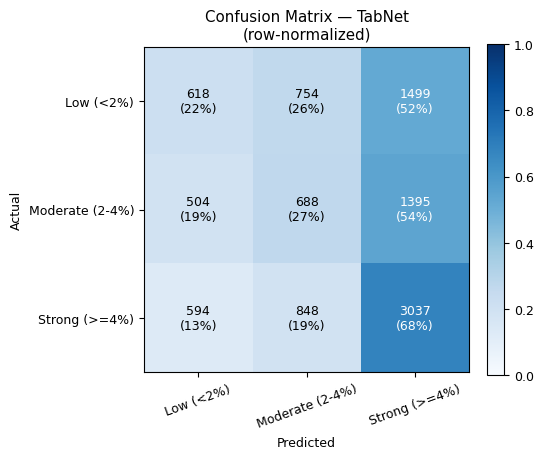

In [17]:
# ── TabNet Confusion Matrix for Presentation ──────────────────────
atrue = results["target_class_actual"].to_numpy()
preds = results["target_class_predicted"].to_numpy()
cm = confusion_matrix(atrue, preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
labels = ["Low (<2%)", "Moderate (2-4%)", "Strong (>=4%)"]
ax.set_xticks(range(3)); ax.set_xticklabels(labels, rotation=20)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — TabNet\n(row-normalized)")
ax.grid(False)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]}\n({cm_pct[i,j]:.0%})", ha="center", va="center",
                color="white" if cm_pct[i,j] > 0.5 else "black")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()
